<a href="https://colab.research.google.com/github/AORA109/Phishing-Website-Detection/blob/main/Phishing_Website_Detection_Training_%26_Testing_Models_on_Datasets(New_DataSets).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Phishing Website Detection by Machine Learning Techniques**

*Final project of AI & Cybersecurity Course*

## **1. Objective:**
Phishing website is one of the internet security problems that target the human vulnerabilities rather than software vulnerabilities. It can be described as the process of attracting online users to obtain their sensitive information such as usernames and passwords. The objective of this project is to train machine learning models and deep neural networks on the dataset created to predict phishing websites. Both phishing and legitimate URLs of websites are gathered to form a dataset and from them required URL and website content-based features are extracted. The performance level of each model is measured and compared.

**NOTE**:
*The required packages for this notebook are imported when needed.*

## **2. Loading Data:**

The features are extracted and saved as a csv file. The working of this can be seen in the **'URL Feature Extraction from Datasets.ipynb'** file.

The reulted csv file is uploaded to this notebook and stored in the dataframe.

In [ ]:
#importing basic packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Loading the data
path = '/content/drive/MyDrive/DoAn_Phishing/DataSets/New_DataSets/PhiUSIIL_Phishing_URL_Dataset.csv'

tuna = pd.read_csv(path)
tuna.head()

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


## **3. Familiarizing with Data**
In this step, few dataframe methods are used to look into the data and its features.

In [ ]:
#Checking the shape of the dataset
tuna.shape

(235795, 56)

In [ ]:
#Listing the features of the dataset
tuna.columns

Index(['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP',
       'TLD', 'URLSimilarityIndex', 'CharContinuationRate',
       'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain',
       'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio',
       'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL',
       'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL',
       'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL',
       'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength',
       'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore',
       'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect',
       'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame',
       'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton',
       'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto',
       'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef',
       'NoOfEmptyRef', 'NoOf

In [ ]:
#Information about the dataset
tuna.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 56 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   FILENAME                    235795 non-null  object 
 1   URL                         235795 non-null  object 
 2   URLLength                   235795 non-null  int64  
 3   Domain                      235795 non-null  object 
 4   DomainLength                235795 non-null  int64  
 5   IsDomainIP                  235795 non-null  int64  
 6   TLD                         235795 non-null  object 
 7   URLSimilarityIndex          235795 non-null  float64
 8   CharContinuationRate        235795 non-null  float64
 9   TLDLegitimateProb           235795 non-null  float64
 10  URLCharProb                 235795 non-null  float64
 11  TLDLength                   235795 non-null  int64  
 12  NoOfSubDomain               235795 non-null  int64  
 13  HasObfuscation

## **4. Visualizing the data**
Few plots and graphs are displayed to find how the data is distributed and the how features are related to each other.

In [ ]:
import os
import pandas as pd

# --- Dán đường dẫn file chính xác của bạn vào giữa 2 dấu nháy ---
duong_dan = '/content/drive/MyDrive/DoAn_Phishing/DataSets/New_DataSets/PhiUSIIL_Phishing_URL_Dataset.csv'
# -------------------------------------------------------------

print(f"Đang kiểm tra đường dẫn: {duong_dan}")

if os.path.exists(duong_dan):
    size = os.path.getsize(duong_dan)
    print(f"✅ Tìm thấy file! Kích thước: {size} bytes")

    if size == 0:
        print("❌ CẢNH BÁO: File này rỗng (0 bytes). Hãy tải lại file lên Drive!")
    else:
        try:
            # Thử đọc 5 dòng đầu
            df = pd.read_csv(duong_dan)
            print(f"✅ Đọc thành công! File có {len(df)} dòng dữ liệu.")
            print("5 dòng đầu tiên là:")
            print(df.head())
        except Exception as e:
            print("❌ File có dữ liệu nhưng không đọc được. Lỗi chi tiết:", e)
else:
    print("❌ Không tìm thấy file! Bạn hãy kiểm tra lại đường dẫn hoặc xem đã Mount Drive chưa.")

Đang kiểm tra đường dẫn: /content/drive/MyDrive/DoAn_Phishing/DataSets/New_DataSets/PhiUSIIL_Phishing_URL_Dataset.csv
✅ Tìm thấy file! Kích thước: 56854345 bytes
✅ Đọc thành công! File có 235795 dòng dữ liệu.
5 dòng đầu tiên là:
     FILENAME                                 URL  URLLength  \
0  521848.txt    https://www.southbankmosaics.com         31   
1   31372.txt            https://www.uni-mainz.de         23   
2  597387.txt      https://www.voicefmradio.co.uk         29   
3  554095.txt         https://www.sfnmjournal.com         26   
4  151578.txt  https://www.rewildingargentina.org         33   

                       Domain  DomainLength  IsDomainIP  TLD  \
0    www.southbankmosaics.com            24           0  com   
1            www.uni-mainz.de            16           0   de   
2      www.voicefmradio.co.uk            22           0   uk   
3         www.sfnmjournal.com            19           0  com   
4  www.rewildingargentina.org            26           0  org   

 

In [ ]:
#Plotting the data distribution
tuna = pd.read_csv('/content/drive/MyDrive/DoAn_Phishing/DataSets/New_DataSets/PhiUSIIL_Phishing_URL_Dataset.csv')
tuna.head()

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


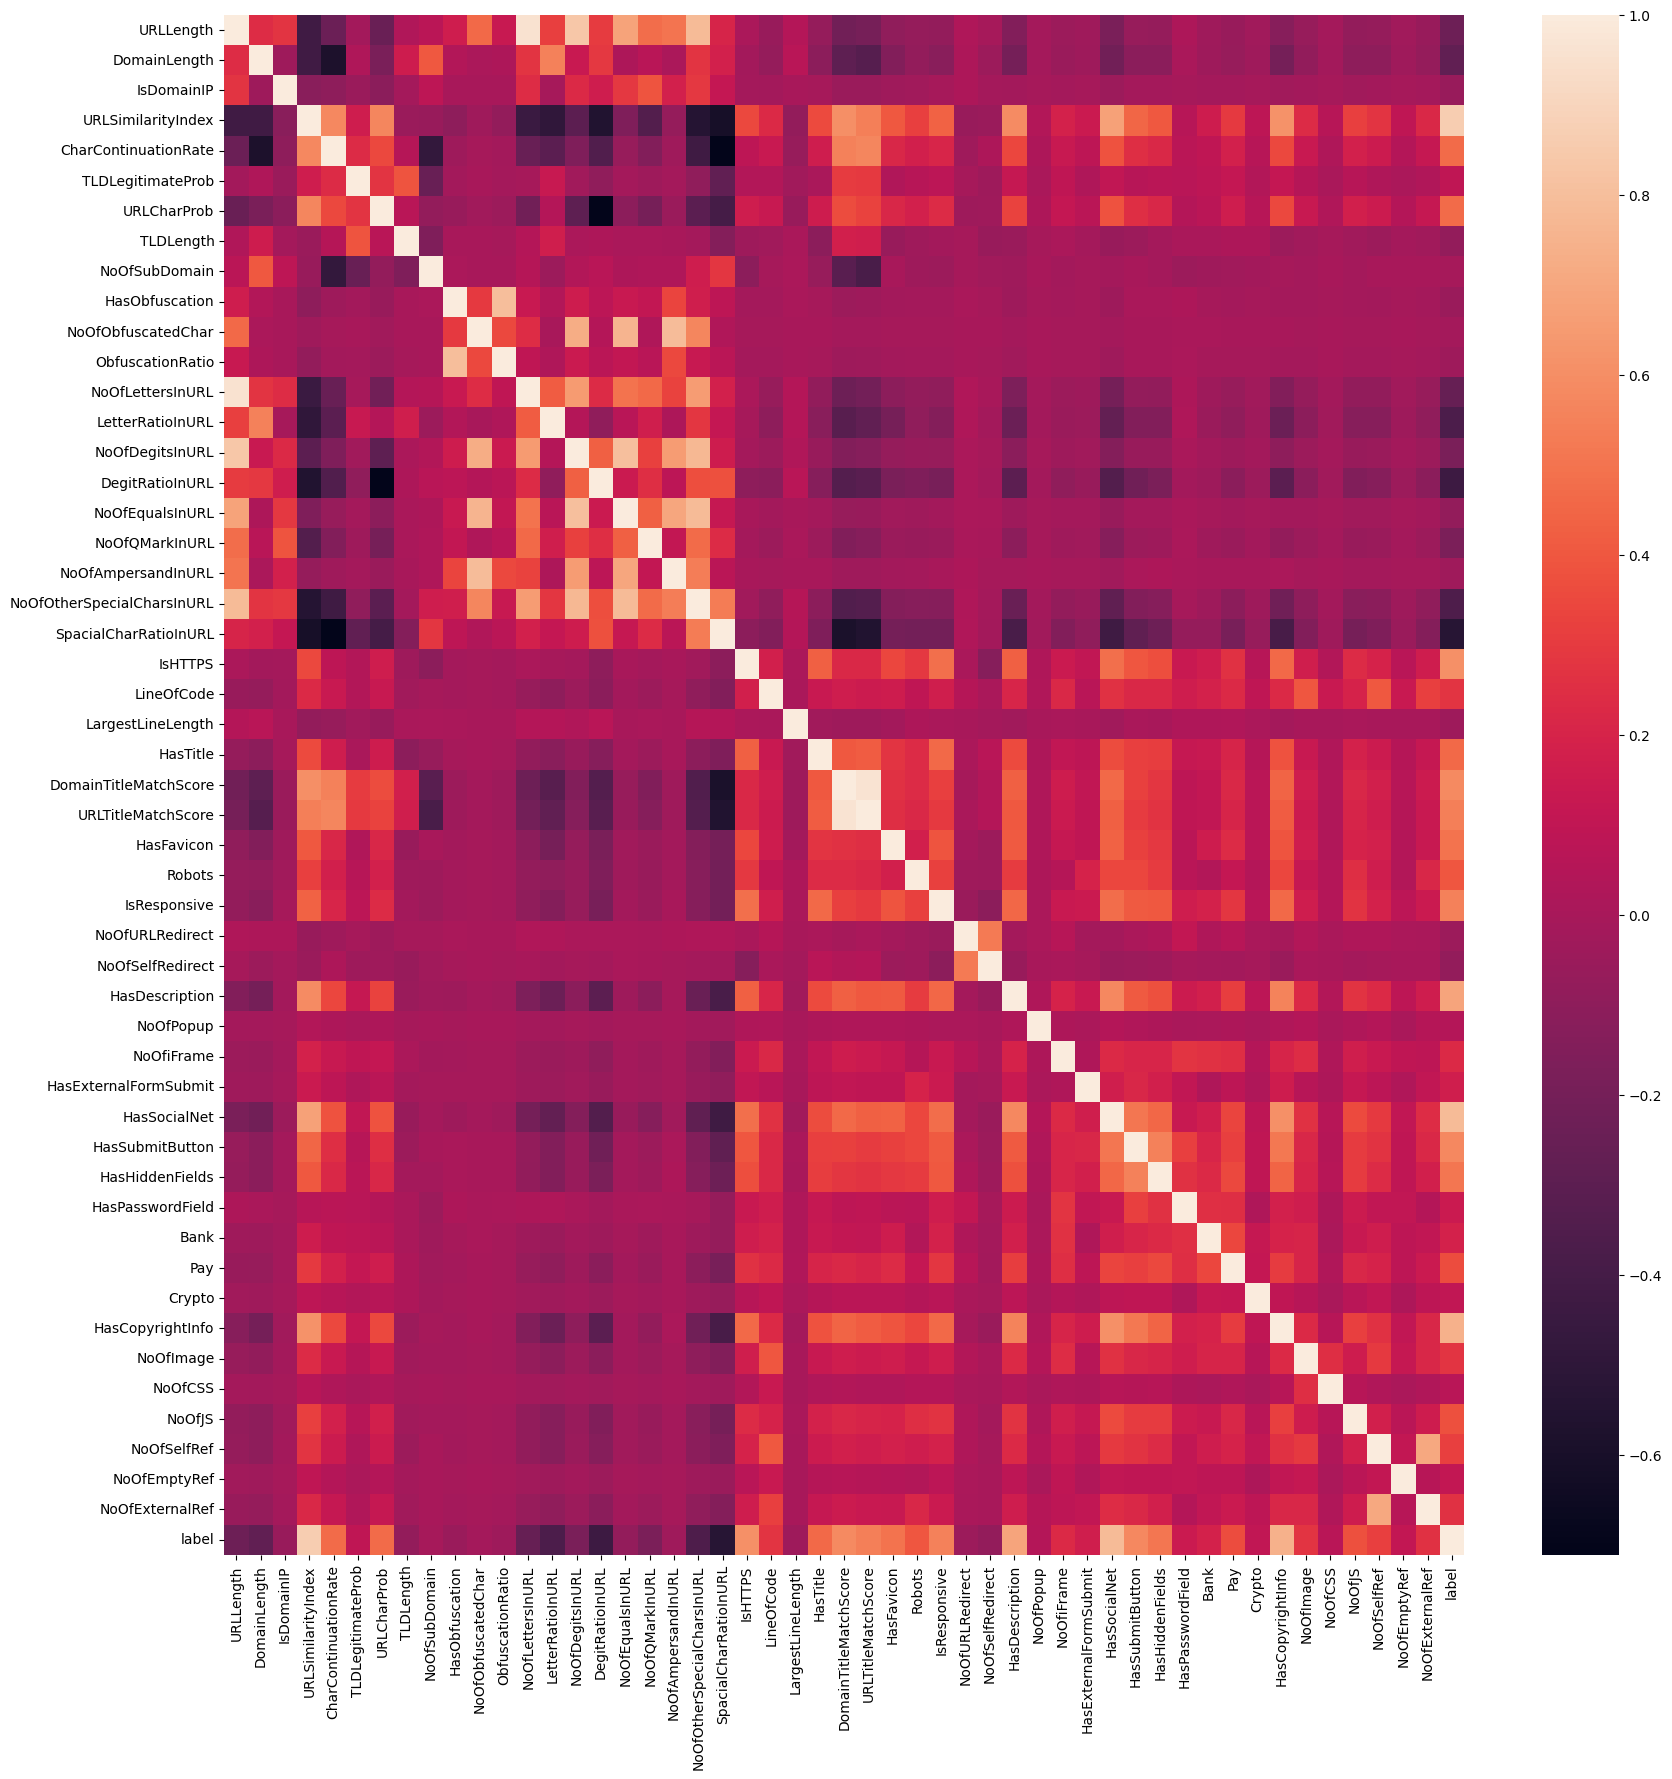

In [ ]:
#Correlation heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 20))

# Thêm numeric_only=True vào đây
sns.heatmap(tuna.corr(numeric_only=True), annot=False)

plt.show()

## **5. Data Preprocessing & EDA**
Here, we clean the data by applying data preprocesssing techniques and transform the data to use it in the models.

In [ ]:
tuna.describe()

,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
count,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,...,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000
mean,34.573095,21.470396,0.002706,78.430778,0.845508,0.260423,0.055747,2.764456,1.164758,0.002057,...,0.237007,0.023474,0.486775,26.075689,6.333111,10.522305,65.071113,2.377629,49.262516,0.571895
std,41.314153,9.150793,0.051946,28.976055,0.216632,0.251628,0.010587,0.599739,0.600969,0.045306,...,0.425247,0.151403,0.499826,79.411815,74.866296,22.312192,176.687539,17.641097,161.027430,0.494805
min,13.000000,4.000000,0.000000,0.155574,0.000000,0.000000,0.001083,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,16.000000,0.000000,57.024793,0.680000,0.005977,0.050747,2.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,27.000000,20.000000,0.000000,100.000000,1.000000,0.079963,0.057970,3.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,8.000000,2.000000,6.000000,12.000000,0.000000,10.000000,1.000000
75%,34.000000,24.000000,0.000000,100.000000,1.000000,0.522907,0.062875,3.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,29.000000,8.000000,15.000000,88.000000,1.000000,57.000000,1.000000
max,6097.000000,110.000000,1.000000,100.000000,1.000000,0.522907,0.090824,13.000000,10.000000,1.000000,...,1.000000,1.000000,1.000000,8956.000000,35820.000000,6957.000000,27397.000000,4887.000000,27516.000000,1.000000


The above obtained result shows that the most of the data is made of 0's & 1's except 'Domain' & 'URL_Depth' columns. The Domain column doesnt have any significance to the machine learning model training. So dropping the *'Domain'* column from the dataset.

In [ ]:
#Dropping the Domain column
dfsa = tuna.drop(['Domain'], axis = 1).copy()

This leaves us with 16 features & a target column. The *'URL_Depth'* maximum value is 20. According to my understanding, there is no necessity to change this column.

In [ ]:
#checking the data for null or missing values
dfsa.isnull().sum()

,0
FILENAME,0
URL,0
URLLength,0
DomainLength,0
IsDomainIP,0
TLD,0
URLSimilarityIndex,0
CharContinuationRate,0
TLDLegitimateProb,0
URLCharProb,0


In the feature extraction file, the extracted features of legitmate & phishing url datasets are just concatenated without any shuffling. This resulted in top 5000 rows of legitimate url data & bottom 5000 of phishing url data.

To even out the distribution while splitting the data into training & testing sets, we need to shuffle it. This even evades the case of overfitting while model training.

In [ ]:
# shuffling the rows in the dataset so that when splitting the train and test set are equally distributed
dfsa = dfsa.sample(frac=1).reset_index(drop=True)
dfsa.head()

,FILENAME,URL,URLLength,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,587566.txt,https://www.hornungs.com,23,16,0,com,100.000000,1.000000,0.522907,0.059441,...,1,0,1,35,2,16,185,2,8,1
1,623703.txt,https://www.estatebeads.com,26,19,0,com,100.000000,1.000000,0.522907,0.067783,...,1,0,1,46,4,24,302,5,23,1
2,mw26897.txt,http://www.venoxcontrol.com,26,20,0,com,67.601103,1.000000,0.522907,0.066751,...,0,0,0,0,0,0,0,0,0,0
3,397362.txt,https://www.essentialhome.eu,27,20,0,eu,100.000000,1.000000,0.005616,0.068403,...,0,0,0,112,4,24,120,0,59,1
4,8122404.txt,https://bafybeihxptow7hycar3aghbxd4xvws4sucyqh...,83,74,0,link,11.021183,0.217391,0.000331,0.033741,...,1,0,0,1,0,2,0,1,1,0


Đang vẽ biểu đồ phân phối cho tất cả các đặc trưng...


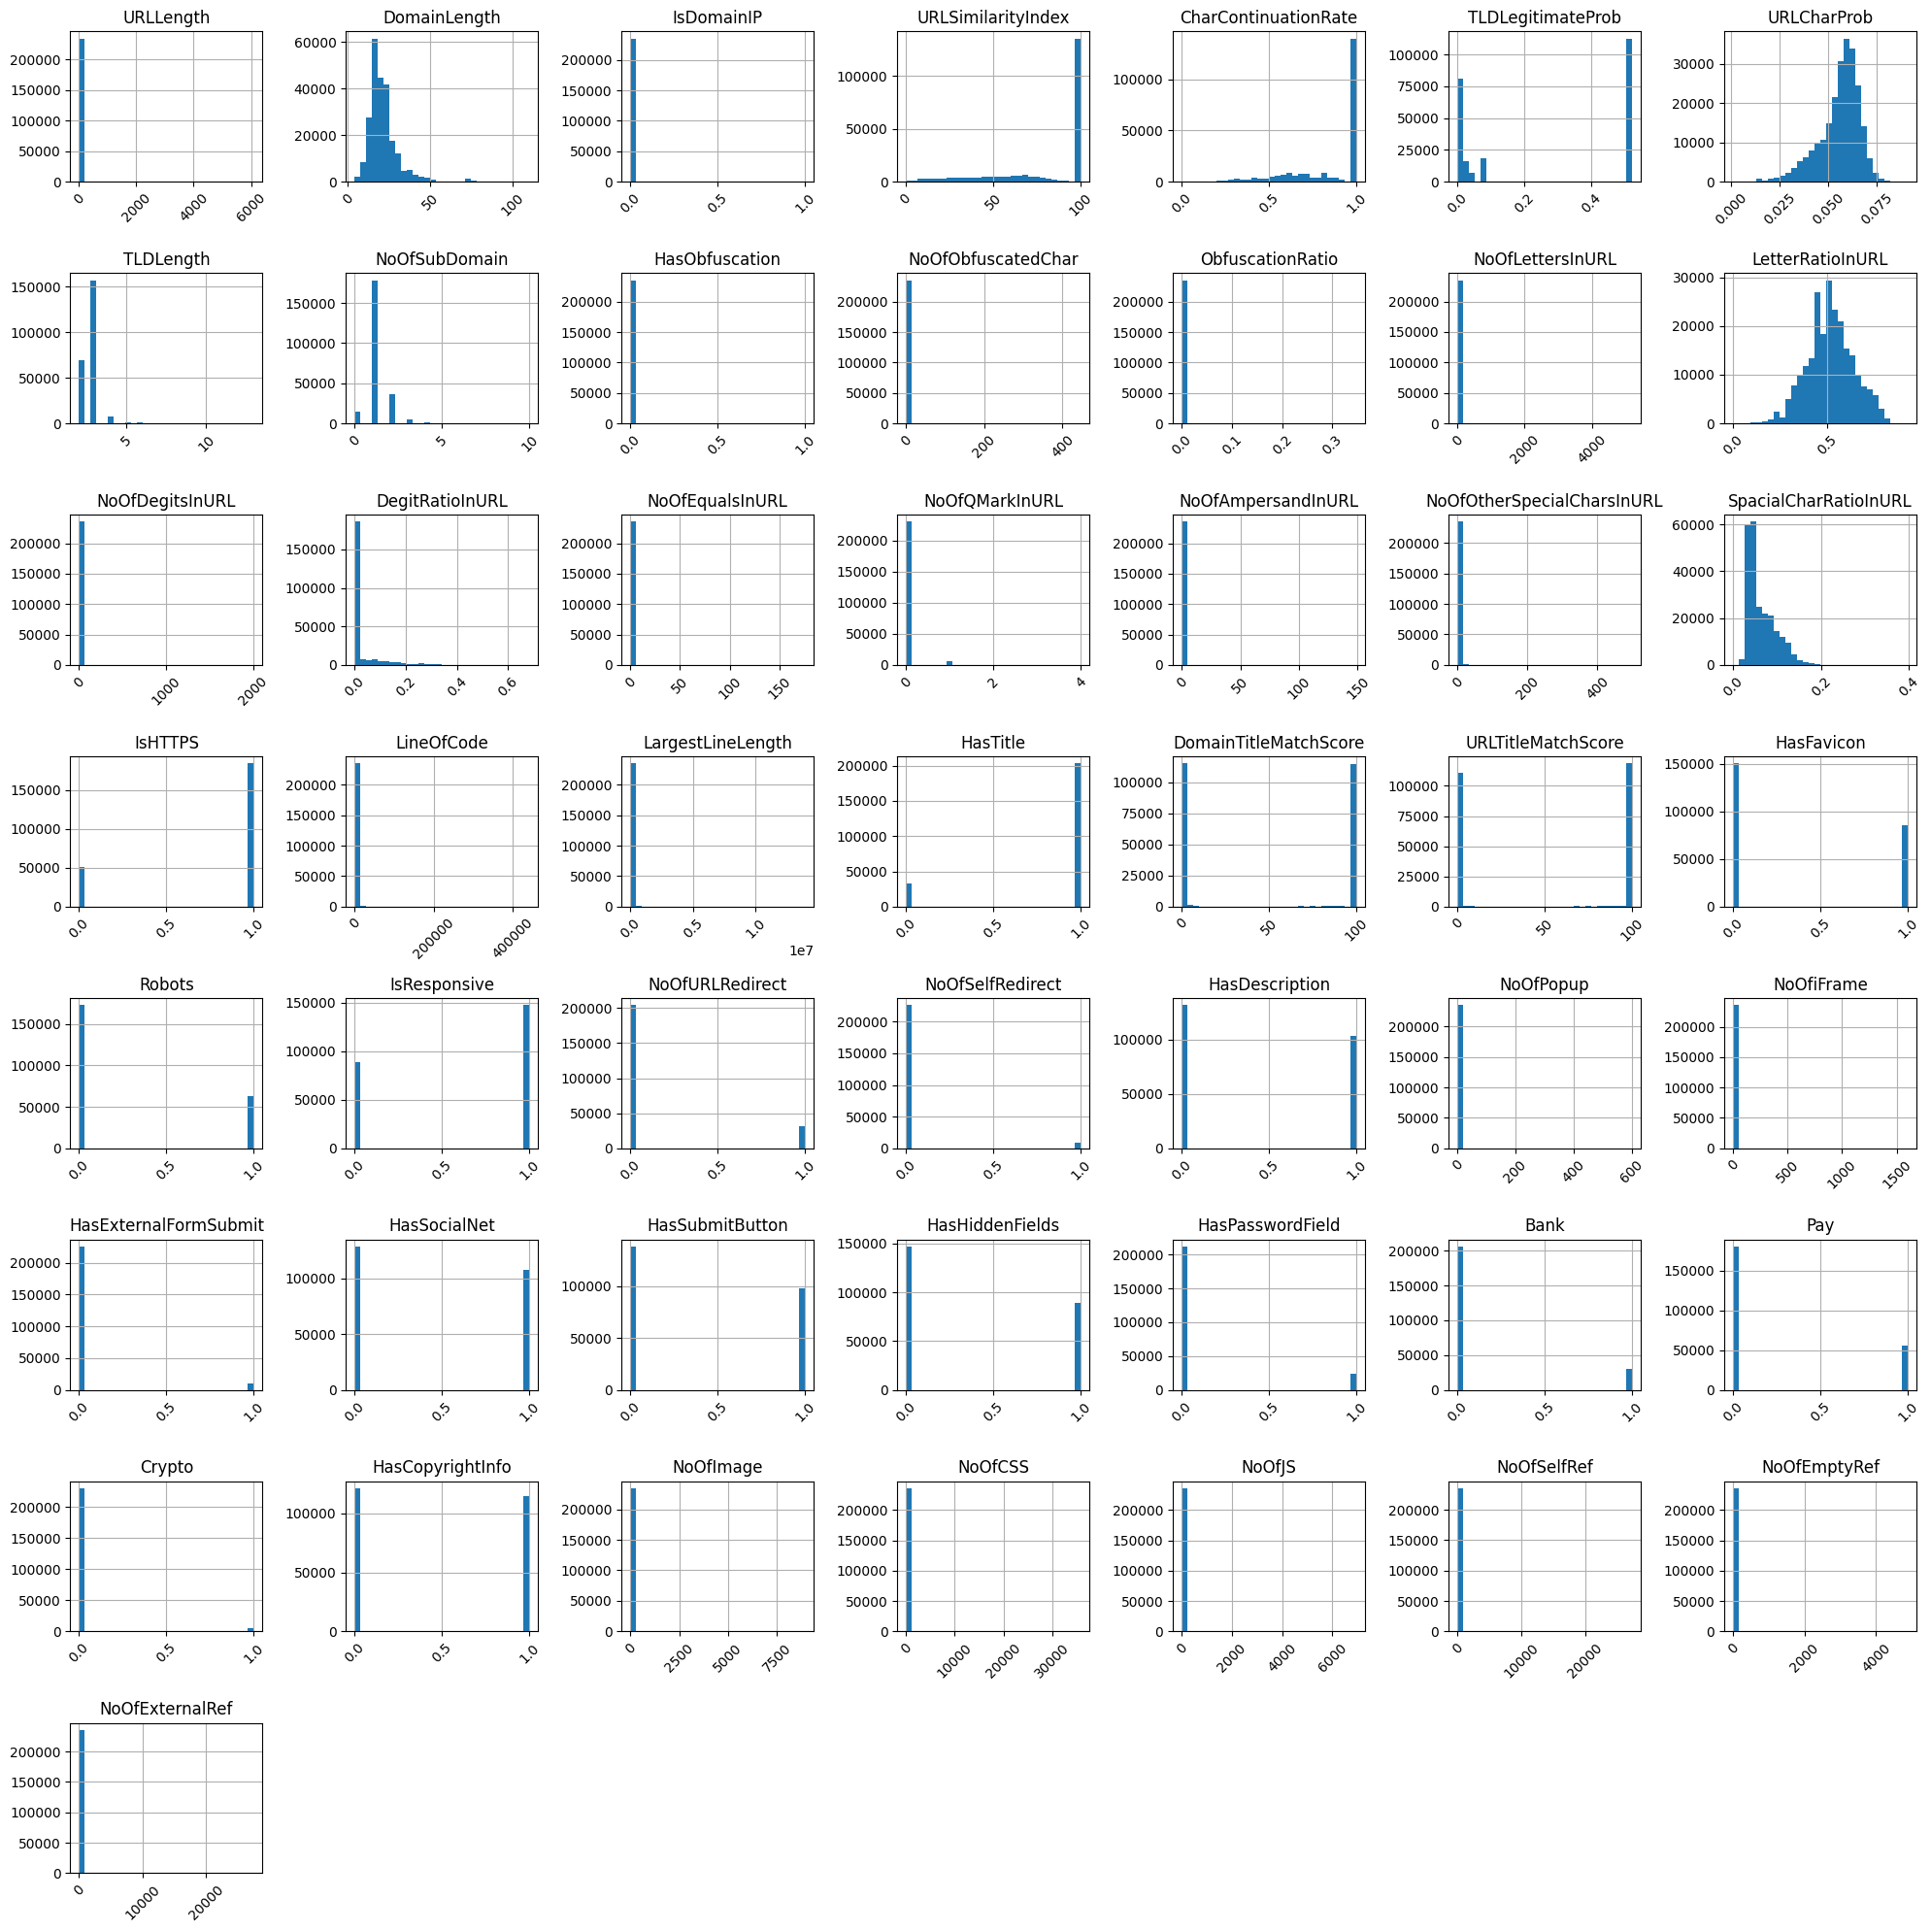

In [ ]:
import matplotlib.pyplot as plt

# --- VẼ BIỂU ĐỒ PHÂN PHỐI (HISTOGRAM) ---
print("Đang vẽ biểu đồ phân phối cho tất cả các đặc trưng...")

# Lệnh vẽ biểu đồ.
# - figsize=(20, 20): Đặt kích thước ảnh thật to vì bạn có hơn 50 cột.
# - bins=30: Chia dữ liệu thành 30 cột nhỏ để nhìn rõ độ phân bổ.
# - xrot=45: Xoay nhãn trục X một chút cho đỡ bị chồng chéo (tùy chọn)
X.hist(figsize=(20, 20), bins=30, xrot=45)

# Hiển thị biểu đồ
plt.tight_layout() # Giúp các biểu đồ con không bị đè lên nhau
plt.show()

Hence, from our Dataset above, it is clear that the data does not have any missing values.

Thus, the data is throughly preprocessed & is ready for training.

## **6. Splitting the Data**

In [ ]:
# Sepratating & assigning features and target columns to X & y
y = dfsa['label']  #target variable
X = dfsa.drop('label',axis=1)   #independent variable


In [ ]:
# Checking the shape for X, y variable
X.shape, y.shape

((235795, 54), (235795,))

In [ ]:
# Splitting the dataset into train and test sets: 80-20 split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 12)  #test-size 20%
X_train.shape, X_test.shape

((188636, 54), (47159, 54))

## **7. Machine Learning Models & Training**

From the dataset above, it is clear that this is a supervised machine learning task. There are two major types of supervised machine learning problems, called classification and regression.

This data set comes under classification problem, as the input URL is classified as phishing (1) or legitimate (0). The supervised machine learning models (classification) considered to train the dataset in this notebook are:
* Decision Tree
* Random Forest
* Multilayer Perceptrons
* XGBoost
* Autoencoder Neural Network
* Support Vector Machines

In [ ]:
#importing packages
from sklearn.metrics import accuracy_score

In [ ]:
# Creating holders to store the model performance results
ML_Model = []
acc_train = []
acc_test = []

#function to call for storing the results
def storeResults(model, a,b):
  ML_Model.append(model)
  acc_train.append(round(a, 3))
  acc_test.append(round(b, 3))

### **7.1. Decision Tree Classifier**
 Decision trees are widely used models for classification and regression tasks. Essentially, they learn a hierarchy of if/else questions, leading to a decision. Learning a decision tree means learning the sequence of if/else questions that gets us to the true answer most quickly.

In the machine learning setting, these questions are called tests (not to be confused with the test set, which is the data we use to test to see how generalizable our model is). To build a tree, the algorithm searches over all possible tests and finds the one that is most informative about the target variable.

In [ ]:
# --- BƯỚC 1: XỬ LÝ DỮ LIỆU ĐẦU VÀO (QUAN TRỌNG NHẤT) ---
# 1. Tách cột kết quả (nhãn) ra riêng
y = dfsa['label']

# 2. Lấy dữ liệu train (X) và TỰ ĐỘNG LỌC CHỈ LẤY SỐ
# Lệnh .select_dtypes(include=['number']) sẽ tự động vứt bỏ mọi cột chữ (TLD, Title, URL...)
# giúp bạn không bao giờ bị lỗi 'could not convert string' nữa.
X = dfsa.drop(['label'], axis=1, errors='ignore').select_dtypes(include=['number'])

print("Đã lọc sạch cột chữ!")
print(f"Số lượng cột còn lại để train: {X.shape[1]}")

# --- BƯỚC 2: CHIA TẬP VÀ TRAIN (GIỮ NGUYÊN) ---
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- BƯỚC 3: HUẤN LUYỆN MÔ HÌNH ---
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)

print("Đang huấn luyện mô hình Decision Tree...")
tree_model.fit(X_train, y_train)

print("Đã train thành công! Không còn lỗi nữa.")

Đã lọc sạch cột chữ!
Số lượng cột còn lại để train: 50
Đang huấn luyện mô hình Decision Tree...
Đã train thành công! Không còn lỗi nữa.


In [ ]:
# --- BƯỚC 4: DỰ ĐOÁN VÀ ĐÁNH GIÁ (Dùng đúng tên tree_model) ---
from sklearn.metrics import accuracy_score, classification_report

# 1. Dùng mô hình đã train (tree_model) để dự đoán
y_test_pred = tree_model.predict(X_test)
y_train_pred = tree_model.predict(X_train)

# 2. Tính điểm độ chính xác
acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_test_pred)

print(f"Độ chính xác trên tập Train: {acc_train*100:.2f}%")
print(f"Độ chính xác trên tập Test:  {acc_test*100:.2f}%")

print("\n--- Báo cáo chi tiết ---")
print(classification_report(y_test, y_test_pred))

Độ chính xác trên tập Train: 100.00%
Độ chính xác trên tập Test:  100.00%

--- Báo cáo chi tiết ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20271
           1       1.00      1.00      1.00     26888

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



**Performance Evaluation:**

In [ ]:
# --- BƯỚC 4: DỰ ĐOÁN (Dùng đúng tên 'tree_model') ---
# Lưu ý: Phải dùng tree_model (mô hình mới) chứ không dùng tree (mô hình cũ)
y_test_tree = tree_model.predict(X_test)
y_train_tree = tree_model.predict(X_train)

# --- BƯỚC 5: TÍNH ĐIỂM CHÍNH XÁC ---
from sklearn.metrics import accuracy_score

acc_train_tree = accuracy_score(y_train, y_train_tree)
acc_test_tree = accuracy_score(y_test, y_test_tree)

print(f"Decision Tree: Accuracy on training Data: {acc_train_tree:.3f}")
print(f"Decision Tree: Accuracy on test Data: {acc_test_tree:.3f}")

Decision Tree: Accuracy on training Data: 1.000
Decision Tree: Accuracy on test Data: 1.000


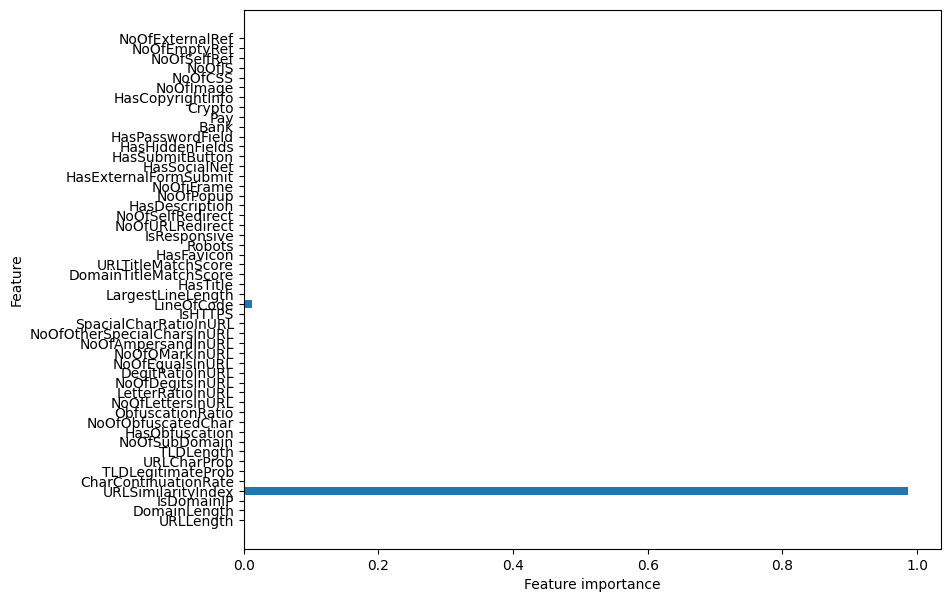

In [ ]:
plt.figure(figsize=(9,7))
n_features = X_train.shape[1]
plt.barh(range(n_features), tree_model.feature_importances_, align='center')
plt.yticks(np.arange(n_features), X_train.columns)
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.show()

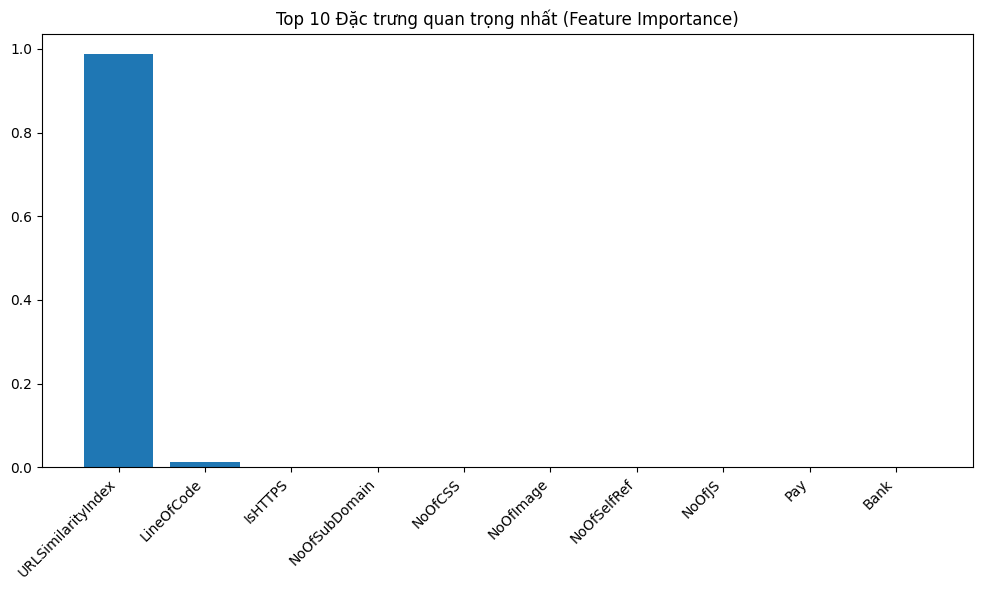

In [ ]:
# --- BƯỚC 6: VẼ BIỂU ĐỒ CÁC ĐẶC TRƯNG QUAN TRỌNG (TOP 10) ---
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Lấy độ quan trọng từ mô hình đã train (Dùng đúng tên 'tree_model')
importances = tree_model.feature_importances_

# 2. Sắp xếp thứ tự từ cao xuống thấp
indices = np.argsort(importances)[::-1]

# 3. Chỉ lấy 10 đặc trưng quan trọng nhất để vẽ cho đẹp
top_n = 10
top_indices = indices[:top_n]

plt.figure(figsize=(10, 6))
plt.title("Top 10 Đặc trưng quan trọng nhất (Feature Importance)")

# Vẽ biểu đồ cột
plt.bar(range(top_n), importances[top_indices], align="center")

# Gán tên cột (feature names) vào trục hoành
plt.xticks(range(top_n), X_train.columns[top_indices], rotation=45, ha='right')

plt.tight_layout()
plt.show()

**Storing the results:**

In [ ]:
# 1. Khởi tạo lại các danh sách lưu trữ (để biến chúng thành List trở lại)
ML_Model = []
acc_train = []
acc_test = []

# 2. Giờ thì lưu kết quả lại, code sẽ chạy ngon lành
storeResults('Decision Tree', acc_train_tree, acc_test_tree)

print("Danh sách kết quả:", acc_train)

Danh sách kết quả: [1.0]


### **7.2. Random Forest Classifier**
Random forests for regression and classification are currently among the most widely used machine learning methods.A random forest is essentially a collection of decision trees, where each tree is slightly different from the others. The idea behind random forests is that each tree might do a relatively good job of predicting, but will likely overfit on part of the data.

If we build many trees, all of which work well and overfit in different ways, we can reduce the amount of overfitting by averaging their results. To build a random forest model, you need to decide on the number of trees to build (the n_estimators parameter of RandomForestRegressor or RandomForestClassifier). They are very powerful, often work well without heavy tuning of the parameters, and don’t require scaling of the data.

In [ ]:
# Random Forest model
from sklearn.ensemble import RandomForestClassifier

# instantiate the model
forest = RandomForestClassifier(max_depth=5)

# fit the model
forest.fit(X_train, y_train)

RandomForestClassifier(max_depth=5)

In [ ]:
#predicting the target value from the model for the samples
y_test_forest = forest.predict(X_test)
y_train_forest = forest.predict(X_train)

**Performance Evaluation:**

In [ ]:
#computing the accuracy of the model performance
acc_train_forest = accuracy_score(y_train,y_train_forest)
acc_test_forest = accuracy_score(y_test,y_test_forest)

print("Random forest: Accuracy on training Data: {:.3f}".format(acc_train_forest))
print("Random forest: Accuracy on test Data: {:.3f}".format(acc_test_forest))

Random forest: Accuracy on training Data: 1.000
Random forest: Accuracy on test Data: 1.000


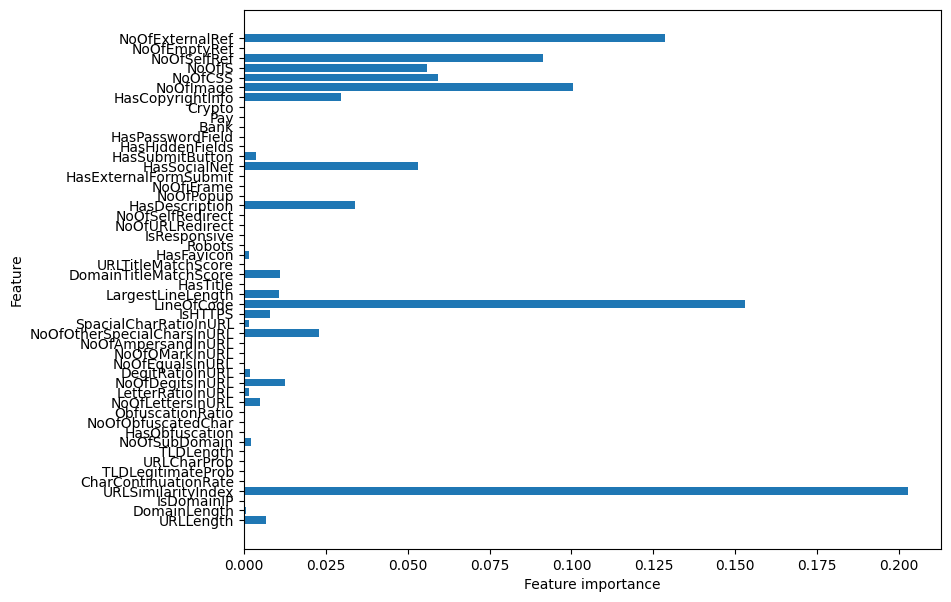

In [ ]:
#checking the feature  importance  in the model
plt.figure(figsize=(9,7))
n_features = X_train.shape[1]
plt.barh(range(n_features), forest.feature_importances_, align='center')
plt.yticks(np.arange(n_features), X_train.columns)
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.show()

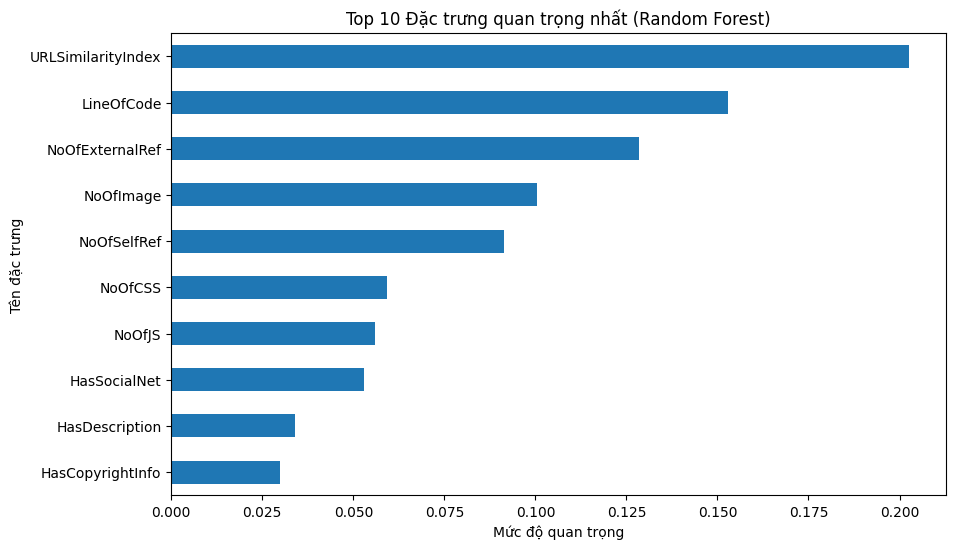

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Gom tên cột và độ quan trọng vào chung 1 biến cho dễ xử lý
# LƯU Ý: Nếu mô hình của bạn tên là 'tree_model' thì sửa chữ 'forest' thành 'tree_model' nhé!
feat_importances = pd.Series(forest.feature_importances_, index=X_train.columns)

# 2. Lấy 10 đặc trưng cao nhất (nlargest)
# .sort_values(ascending=True) giúp cái quan trọng nhất nằm trên cùng khi vẽ barh
top_10 = feat_importances.nlargest(10).sort_values(ascending=True)

# 3. Vẽ biểu đồ
plt.figure(figsize=(10, 6))
top_10.plot(kind='barh') # Dùng hàm vẽ có sẵn của Pandas cực nhanh

plt.title("Top 10 Đặc trưng quan trọng nhất (Random Forest)")
plt.xlabel("Mức độ quan trọng")
plt.ylabel("Tên đặc trưng")
plt.show()

**Storing the results:**

In [ ]:
#storing the results. The below mentioned order of parameter passing is important.
#Caution: Execute only once to avoid duplications.
storeResults('Random Forest', acc_train_forest, acc_test_forest)

### **7.3. Multilayer Perceptrons (MLPs): Deep Learning**
Multilayer perceptrons (MLPs) are also known as (vanilla) feed-forward neural networks, or sometimes just neural networks. Multilayer perceptrons can be applied for both classification and regression problems.

MLPs can be viewed as generalizations of linear models that perform multiple stages of processing to come to a decision.

In [ ]:
# Multilayer Perceptrons model
from sklearn.neural_network import MLPClassifier

# instantiate the model
mlp = MLPClassifier(alpha=0.001, hidden_layer_sizes=([100,100,100]))

# fit the model
mlp.fit(X_train, y_train)

MLPClassifier(alpha=0.001, hidden_layer_sizes=[100, 100, 100])

In [ ]:
#predicting the target value from the model for the samples
y_test_mlp = mlp.predict(X_test)
y_train_mlp = mlp.predict(X_train)

**Performance Evaluation:**

In [ ]:
#computing the accuracy of the model performance
acc_train_mlp = accuracy_score(y_train,y_train_mlp)
acc_test_mlp = accuracy_score(y_test,y_test_mlp)

print("Multilayer Perceptrons: Accuracy on training Data: {:.3f}".format(acc_train_mlp))
print("Multilayer Perceptrons: Accuracy on test Data: {:.3f}".format(acc_test_mlp))

Multilayer Perceptrons: Accuracy on training Data: 1.000
Multilayer Perceptrons: Accuracy on test Data: 1.000


**Storing the results:**

In [ ]:
#storing the results. The below mentioned order of parameter passing is important.
#Caution: Execute only once to avoid duplications.
storeResults('Multilayer Perceptrons', acc_train_mlp, acc_test_mlp)

### **7.4. XGBoost Classifier**
XGBoost is one of the most popular machine learning algorithms these days. XGBoost stands for eXtreme Gradient Boosting. Regardless of the type of prediction task at hand; regression or classification. XGBoost is an implementation of gradient boosted decision trees designed for speed and performance.

In [ ]:
!pip install xgboost

In [ ]:
#XGBoost Classification model
from xgboost import XGBClassifier

# instantiate the model
xgb = XGBClassifier(learning_rate=0.4,max_depth=7)
#fit the model
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.4, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
#predicting the target value from the model for the samples
y_test_xgb = xgb.predict(X_test)
y_train_xgb = xgb.predict(X_train)

**Performance Evaluation:**

In [ ]:
#computing the accuracy of the model performance
acc_train_xgb = accuracy_score(y_train,y_train_xgb)
acc_test_xgb = accuracy_score(y_test,y_test_xgb)

print("XGBoost: Accuracy on training Data: {:.3f}".format(acc_train_xgb))
print("XGBoost : Accuracy on test Data: {:.3f}".format(acc_test_xgb))

XGBoost: Accuracy on training Data: 1.000
XGBoost : Accuracy on test Data: 1.000


**Storing the results:**

In [ ]:
#storing the results. The below mentioned order of parameter passing is important.
#Caution: Execute only once to avoid duplications.
storeResults('XGBoost', acc_train_xgb, acc_test_xgb)

### **7.5. Autoencoder Neural Network**
An auto encoder is a neural network that has the same number of input neurons as it does outputs. The hidden layers of the neural network will have fewer neurons than the input/output neurons. Because there are fewer neurons, the auto-encoder must learn to encode the input to the fewer hidden neurons. The predictors (x) and output (y) are exactly the same in an auto encoder.

In [ ]:
#importing required packages
import keras
from keras.layers import Input, Dense
from keras import regularizers
import tensorflow as tf
from keras.models import Model
from sklearn import metrics

In [ ]:
#building autoencoder model

input_dim = X_train.shape[1]
encoding_dim = input_dim

input_layer = Input(shape=(input_dim, ))
encoder = Dense(encoding_dim, activation="relu",
                activity_regularizer=regularizers.l1(10e-4))(input_layer)
encoder = Dense(int(encoding_dim), activation="relu")(encoder)

encoder = Dense(int(encoding_dim-2), activation="relu")(encoder)
code = Dense(int(encoding_dim-4), activation='relu')(encoder)
decoder = Dense(int(encoding_dim-2), activation='relu')(code)

decoder = Dense(int(encoding_dim), activation='relu')(encoder)
decoder = Dense(input_dim, activation='relu')(decoder)
autoencoder = Model(inputs=input_layer, outputs=decoder)
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 48)             │         2,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 50)             │         2,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 50)             │         2,550 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,548 (49.02 KB)

 Trainable params: 12,548 (49.02 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#compiling the model
autoencoder.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['accuracy'])

#Training the model
history = autoencoder.fit(X_train, X_train, epochs=10, batch_size=64, shuffle=True, validation_split=0.2)

Epoch 1/10
2358/2358 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.0073 - loss: -4133.6274 - val_accuracy: 0.0000e+00 - val_loss: -4401.9102
Epoch 2/10
2358/2358 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.0000e+00 - loss: -4583.6406 - val_accuracy: 0.0000e+00 - val_loss: -4401.9243
Epoch 3/10
2358/2358 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.0000e+00 - loss: -4777.9453 - val_accuracy: 0.0000e+00 - val_loss: -4401.9253
Epoch 4/10
2358/2358 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.0000e+00 - loss: -4760.2158 - val_accuracy: 0.0000e+00 - val_loss: -4401.9287
Epoch 5/10
2358/2358 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 1.9353e-05 - loss: -4700.6118 - val_accuracy: 0.0000e+00 - val_loss: -4401.9287
Epoch 6/10
2358/2358 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.0000e+00 - loss: -4467.7744 - val_accuracy: 0.0000e+00 - val_loss: -4401.9287
Epoch 7/10
2358/2358 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.0000e+00 - loss: -4514.3384 - val_accuracy: 0.0000e+00 - va

**Performance Evaluation:**

In [ ]:
acc_train_auto = autoencoder.evaluate(X_train, X_train)[1]
acc_test_auto = autoencoder.evaluate(X_test, X_test)[1]

print('\nAutoencoder: Accuracy on training Data: {:.3f}' .format(acc_train_auto))
print('Autoencoder: Accuracy on test Data: {:.3f}' .format(acc_test_auto))

5895/5895 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.7263 - loss: -4826.2666
1474/1474 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7308 - loss: -4338.6514

Autoencoder: Accuracy on training Data: 0.727
Autoencoder: Accuracy on test Data: 0.731


**Storing the results:**

In [ ]:
#storing the results. The below mentioned order of parameter passing is important.
#Caution: Execute only once to avoid duplications.
storeResults('AutoEncoder', acc_train_auto, acc_test_auto)

### **7.6. Support Vector Machines**

In machine learning, support-vector machines (SVMs, also support-vector networks) are supervised learning models with associated learning algorithms that analyze data used for classification and regression analysis. Given a set of training examples, each marked as belonging to one or the other of two categories, an SVM training algorithm builds a model that assigns new examples to one category or the other, making it a non-probabilistic binary linear classifier.

In [ ]:
#Support vector machine model
from sklearn.svm import SVC

# instantiate the model
svm = SVC(kernel='linear', C=1.0, random_state=12)
#fit the model
svm.fit(X_train, y_train)

SVC(kernel='linear', random_state=12)

In [ ]:
#predicting the target value from the model for the samples
y_test_svm = svm.predict(X_test)
y_train_svm = svm.predict(X_train)

**Performance Evaluation:**

In [ ]:
#computing the accuracy of the model performance
acc_train_svm = accuracy_score(y_train,y_train_svm)
acc_test_svm = accuracy_score(y_test,y_test_svm)

print("SVM: Accuracy on training Data: {:.3f}".format(acc_train_svm))
print("SVM : Accuracy on test Data: {:.3f}".format(acc_test_svm))

SVM: Accuracy on training Data: 1.000
SVM : Accuracy on test Data: 1.000


**Storing the results:**

In [ ]:
#storing the results. The below mentioned order of parameter passing is important.
#Caution: Execute only once to avoid duplications.
storeResults('SVM', acc_train_svm, acc_test_svm)

8. Confusion matrix of model

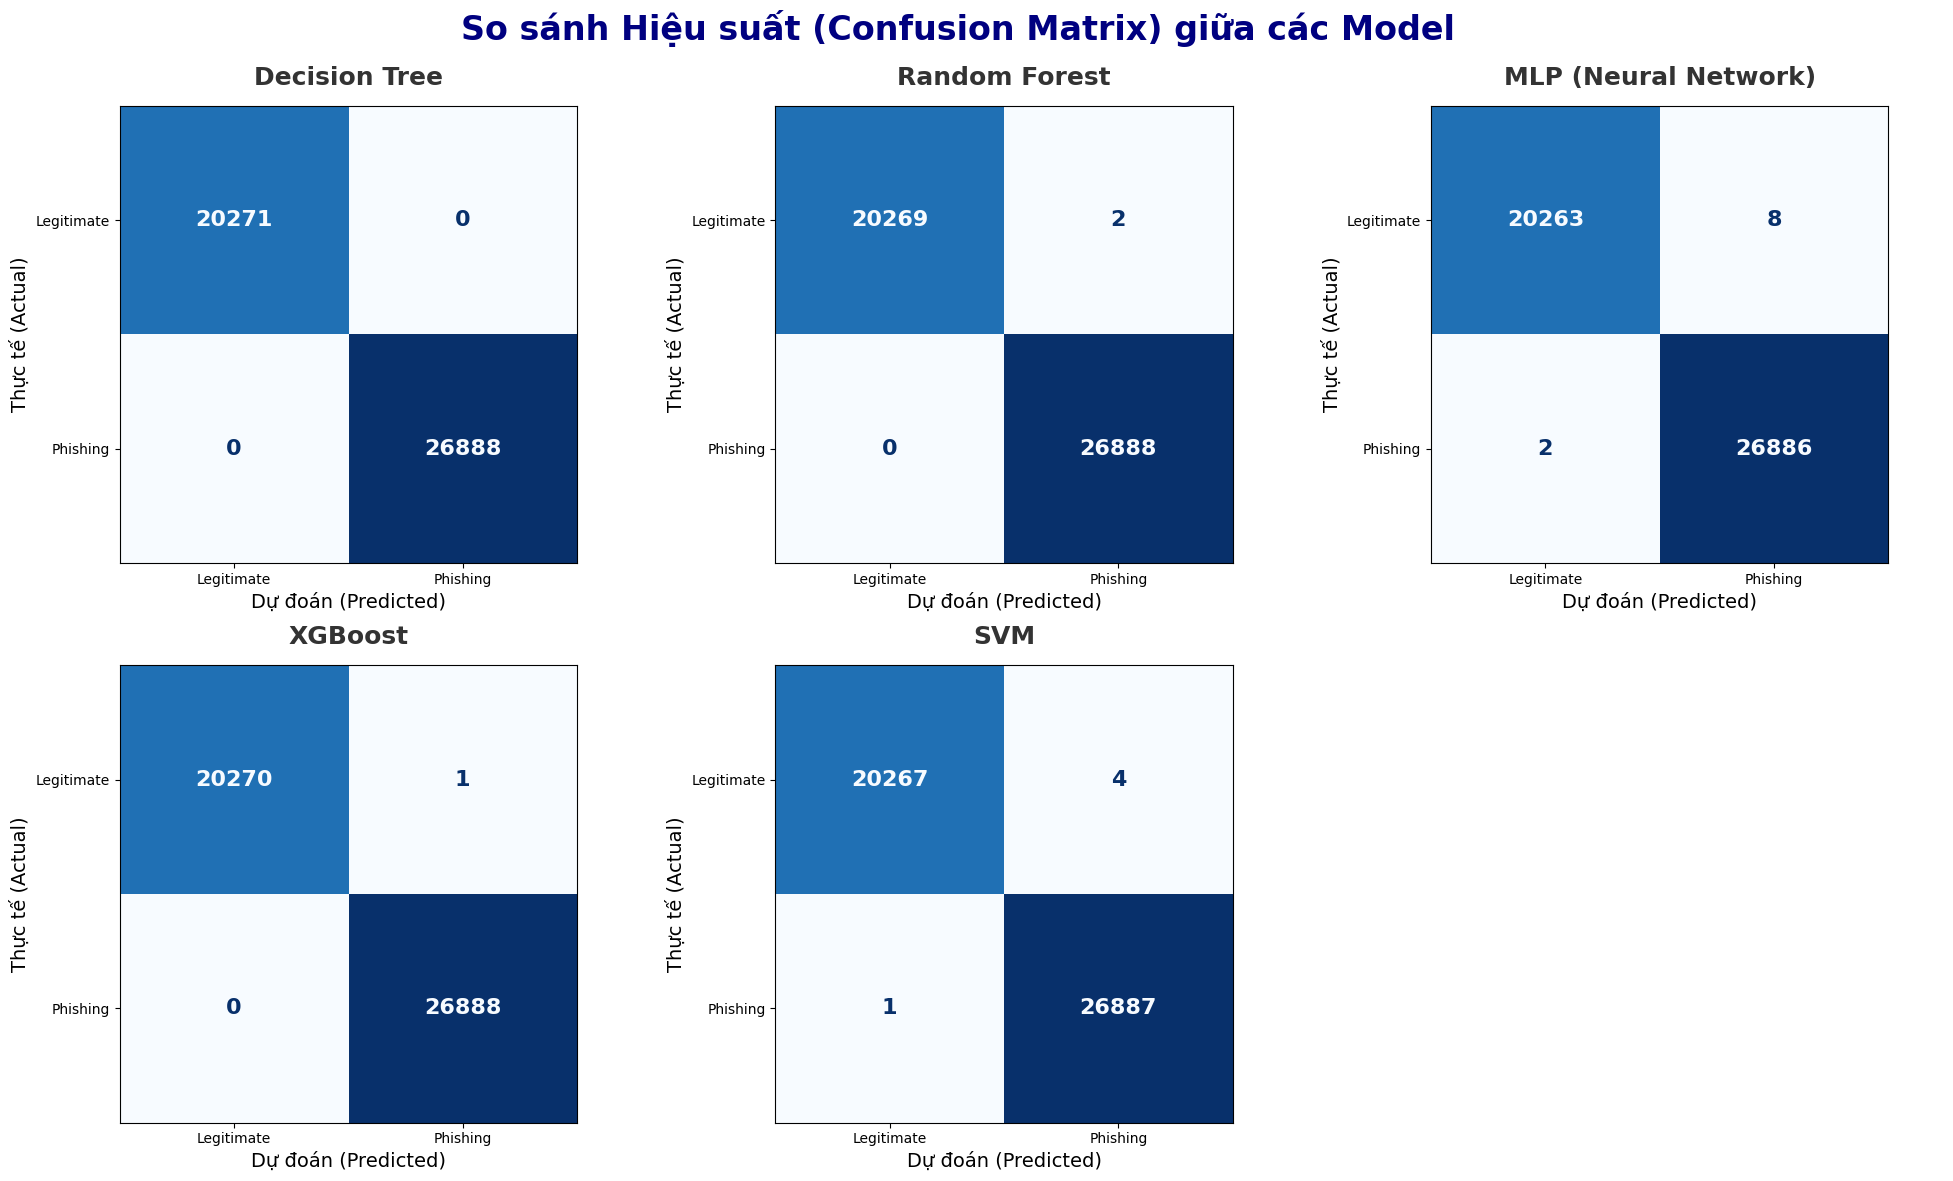

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Danh sách Model (Giữ nguyên như của bạn)
model_list = [
    ("Decision Tree", tree_model),
    ("Random Forest", forest),
    ("MLP (Neural Network)", mlp),
    ("XGBoost", xgb),
    ("SVM", svm)
]

# 2. Thiết lập khung vẽ lớn hơn một chút để thoáng mắt
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 12))

# Tiêu đề chung (đẩy lên cao một chút và in đậm)
fig.suptitle('So sánh Hiệu suất (Confusion Matrix) giữa các Model',
             fontsize=24, fontweight='bold', y=0.98, color='navy')

axes_flat = axes.flatten()

# 3. Vòng lặp vẽ
for i, (name, model) in enumerate(model_list):
    ax = axes_flat[i]

    # Dự đoán
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    # --- PHẦN CHỈNH SỬA QUAN TRỌNG ---
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Legitimate', 'Phishing'])

    # Vẽ biểu đồ
    # - values_format='d': Ép kiểu số nguyên (integer) cho gọn.
    # - text_kw: Từ điển chứa cấu hình font chữ (size to, in đậm).
    # - cmap='Blues': Tông màu xanh dương chuyên nghiệp.
    disp.plot(cmap='Blues', ax=ax, colorbar=False, values_format='d',
              text_kw={'size': 16, 'weight': 'bold'})

    # Trang trí lại tiêu đề và nhãn trục của từng hình con
    ax.set_title(name, fontsize=18, fontweight='bold', pad=15, color='#333333')
    ax.set_xlabel('Dự đoán (Predicted)', fontsize=14, fontweight='medium')
    ax.set_ylabel('Thực tế (Actual)', fontsize=14, fontweight='medium')

    # Tắt lưới (grid) nếu vô tình bị bật, giúp nhìn sạch hơn
    ax.grid(False)

# 4. Xử lý ô thừa
axes_flat[-1].axis('off')

# Căn chỉnh tự động để các hình không đè lên nhau
plt.tight_layout()
# Chừa khoảng trống ở trên đầu cho tiêu đề chính (suptitle)
plt.subplots_adjust(top=0.90)

plt.show()

## **9. Comparision of Models**
To compare the models performance, a dataframe is created. The columns of this dataframe are the lists created to store the results of the model.

In [ ]:
#creating dataframe
results = pd.DataFrame({ 'ML Model': ML_Model,
                         'Train Accuracy': acc_train,
                        'Test Accuracy': acc_test})
results

,ML Model,Train Accuracy,Test Accuracy
0,Decision Tree,1.000,1.000
1,Random Forest,1.000,1.000
2,Multilayer Perceptrons,1.000,1.000
3,XGBoost,1.000,1.000
4,AutoEncoder,0.727,0.731
5,SVM,1.000,1.000


In [ ]:
#Sorting the datafram on accuracy
results.sort_values(by=['Test Accuracy', 'Train Accuracy'], ascending=False)

,ML Model,Train Accuracy,Test Accuracy
0,Decision Tree,1.000,1.000
1,Random Forest,1.000,1.000
2,Multilayer Perceptrons,1.000,1.000
3,XGBoost,1.000,1.000
5,SVM,1.000,1.000
4,AutoEncoder,0.727,0.731


For the above comparision, it is clear that the XGBoost Classifier works well with this dataset.

So, saving the model for future use.

In [ ]:
# save XGBoost model to file
import pickle
pickle.dump(xgb, open("XGBoostClassifier.pickle.dat", "wb"))

**Testing the saved model:**

In [ ]:
# load model from file
loaded_model = pickle.load(open("XGBoostClassifier.pickle.dat", "rb"))
loaded_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.4, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

### **10. References**
*  https://www.irjet.net/archives/V8/i4/IRJET-V8I4274.pdf  --  The Model explained
* https://blog.keras.io/building-autoencoders-in-keras.html
* https://en.wikipedia.org/wiki/Autoencoder
* https://mc.ai/a-beginners-guide-to-build-stacked-autoencoder-and-tying-weights-with-it/
* https://github.com/shreyagopal/t81_558_deep_learning/blob/master/t81_558_class_14_03_anomaly.ipynb
* https://machinelearningmastery.com/save-gradient-boosting-models-xgboost-python/
